Saving food detect.v4-annotations-changed.yolov8.zip to food detect.v4-annotations-changed.yolov8 (1).zip
Dataset ready at: food detect.v4-annotations-changed.yolov8 (1)
Ultralytics 8.4.10 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=food detect.v4-annotations-changed.yolov8 (1)/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, m

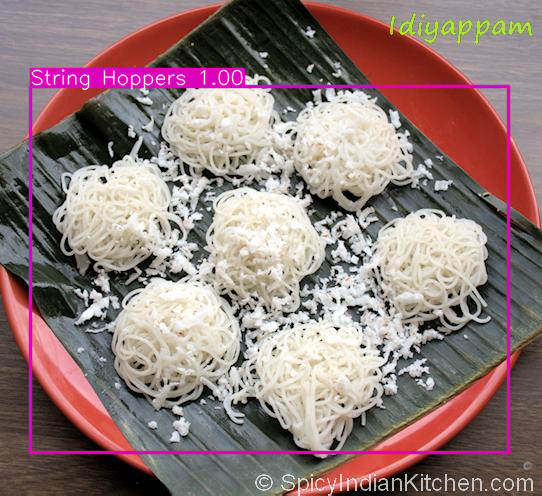

In [2]:
# Step 0: Install packages
!pip install ultralytics roboflow --quiet

# Step 1: Upload your dataset ZIP
from google.colab import files
uploaded = files.upload()  # choose your ZIP file

# Step 2: Unzip the dataset
import zipfile
import os
for fn in uploaded.keys():
    with zipfile.ZipFile(fn, 'r') as zip_ref:
        zip_ref.extractall(fn.replace(".zip",""))

dataset_path = fn.replace(".zip","")
print("Dataset ready at:", dataset_path)

# Step 3: Train a small YOLOv8 model quickly
from ultralytics import YOLO

# Use yolov8n.pt (nano) for very fast training
model = YOLO("yolov8n.pt")

# Quick training settings for testing
model.train(
    data=f"{dataset_path}/data.yaml",  # path to data.yaml
    epochs=30,                          # small number of epochs for fast start
    imgsz=320,                         # smaller images to speed up
    batch=4,                            # smaller batch for Colab free
    project="meal_plate_test",          # save results here
    name="quick_train",
    exist_ok=True
)

# Step 4: Test on one example image
example_image = os.path.join(dataset_path, "valid/images", os.listdir(os.path.join(dataset_path, "valid/images"))[0])
results = model.predict(example_image)
results[0].show()  # show the first (and only) result



Testing on: dhal-curry-3-_jpeg.rf.bc08a7e790dcb30b696169433ae84918.jpg

image 1/1 /content/food detect.v4-annotations-changed.yolov8 (1)/valid/images/dhal-curry-3-_jpeg.rf.bc08a7e790dcb30b696169433ae84918.jpg: 256x320 1 Dhal Curry, 56.8ms
Speed: 1.4ms preprocess, 56.8ms inference, 2.2ms postprocess per image at shape (1, 3, 256, 320)


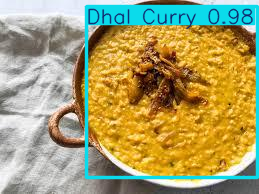

In [3]:
import random
import os

# Pick a random image from your validation set
valid_images_dir = os.path.join(dataset_path, "valid/images")
random_image = random.choice(os.listdir(valid_images_dir))
example_image = os.path.join(valid_images_dir, random_image)

print("Testing on:", random_image)
results = model.predict(example_image)
results[0].show()


Upload new meal plate images (you can select multiple):


Saving cabbagestirfry.jpg to cabbagestirfry (1).jpg
Saving Sri-Lankan-Curry-3.jpg to Sri-Lankan-Curry-3 (2).jpg
Saving wade.jpg to wade.jpg
3 image(s) uploaded for testing.

--- Testing: new_food_images/cabbagestirfry (1).jpg ---

image 1/1 /content/new_food_images/cabbagestirfry (1).jpg: 224x320 1 Cabbage Curry, 7.8ms
Speed: 1.0ms preprocess, 7.8ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 320)

image 1/1 /content/new_food_images/cabbagestirfry (1).jpg: 224x320 1 Cabbage Curry, 5.3ms
Speed: 0.8ms preprocess, 5.3ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 320)


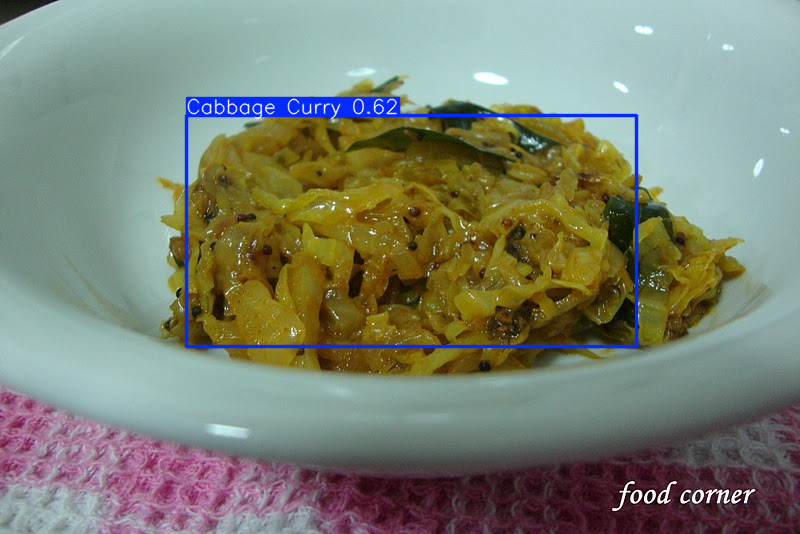

Detected foods:
  - Cabbage Curry, Confidence: 0.62

--- Testing: new_food_images/Sri-Lankan-Curry-3 (2).jpg ---

image 1/1 /content/new_food_images/Sri-Lankan-Curry-3 (2).jpg: 224x320 1 Dhal Curry, 1 Pol Sambol, 2 Red rices, 8.2ms
Speed: 1.2ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 224, 320)

image 1/1 /content/new_food_images/Sri-Lankan-Curry-3 (2).jpg: 224x320 1 Dhal Curry, 1 Pol Sambol, 2 Red rices, 7.2ms
Speed: 1.0ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 224, 320)


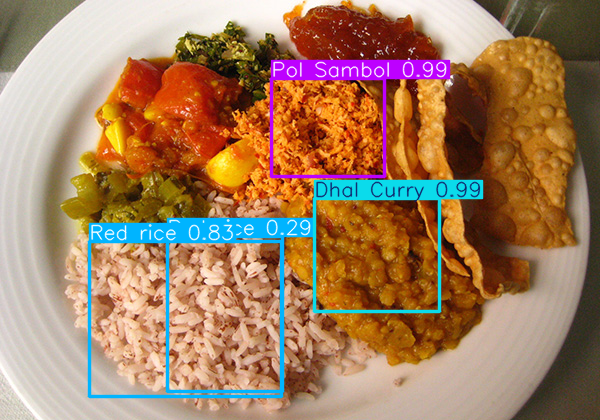

Detected foods:
  - Dhal Curry, Confidence: 0.99
  - Pol Sambol, Confidence: 0.99
  - Red rice, Confidence: 0.83
  - Red rice, Confidence: 0.29

--- Testing: new_food_images/wade.jpg ---

image 1/1 /content/new_food_images/wade.jpg: 224x320 1 Wade, 9.4ms
Speed: 1.4ms preprocess, 9.4ms inference, 2.0ms postprocess per image at shape (1, 3, 224, 320)

image 1/1 /content/new_food_images/wade.jpg: 224x320 1 Wade, 8.1ms
Speed: 1.2ms preprocess, 8.1ms inference, 1.5ms postprocess per image at shape (1, 3, 224, 320)


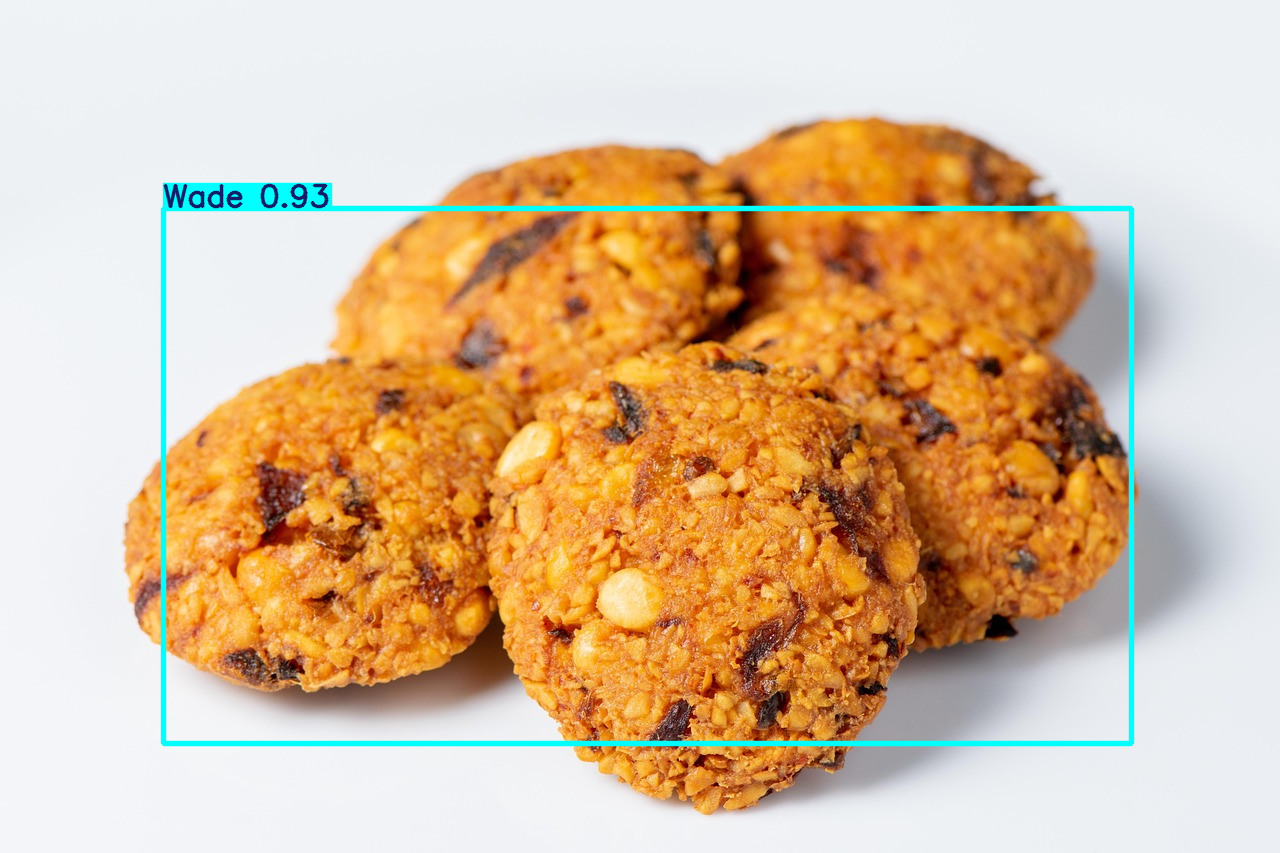

Detected foods:
  - Wade, Confidence: 0.93


In [6]:
# ==========================
# Cell 3: Test on new/unseen images
# ==========================

from ultralytics import YOLO
from google.colab import files
import os

# 1️⃣ Load your trained YOLOv8 model
model = YOLO("/content/runs/detect/meal_plate_test/quick_train/weights/best.pt")

# 2️⃣ Upload one or more new images (simulate user uploads)
print("Upload new meal plate images (you can select multiple):")
uploaded = files.upload()  # user selects image files

# 3️⃣ Create a folder to save uploaded images
os.makedirs("new_food_images", exist_ok=True)

# Save uploaded images
uploaded_files = []
for filename in uploaded.keys():
    path = os.path.join("new_food_images", filename)
    uploaded_files.append(path)
    with open(path, "wb") as f:
        f.write(uploaded[filename])
print(f"{len(uploaded_files)} image(s) uploaded for testing.")

# 4️⃣ Run predictions on each uploaded image
for img_path in uploaded_files:
    print("\n--- Testing:", img_path, "---")
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results[0].show()

    # Print detected foods with confidence scores
    print("Detected foods:")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]
        print(f"  - {class_name}, Confidence: {confidence:.2f}")
